# Analysis Walkthrough: Ketamine-Augmented Prolonged Exposure for PTSD

This notebook provides a detailed, step-by-step walkthrough of the data processing, analysis, and figure generation for the manuscript:
**State-Dependent Resistance to Ketamine-Augmented Psychotherapy: Baseline Network Instability as a Barrier to Recovery in PTSD**

## Theoretical Background
Prolonged Exposure (PE) therapy relies on the consolidation of fear extinction learning, which requires robust structural and functional integrity of the fronto-limbic circuit. Subanesthetic ketamine is a rapid neuroplasticity enhancer hypothesized to "lubricate" these circuits. 

However, this notebook explores the hypothesis that the efficacy of this rescue is **state-dependent**. Specifically, we investigate whether baseline **temporal instability (dynamic Functional Connectivity variance)** between the Salience Network (threat detection) and Default Mode Network (safety contextualization) acts as a definitive prognostic barrier—a level of "neural noise" that pharmacological neuroplasticity cannot override.


---
## Step 1: Loading the Clinical Data

First, we will load the clinical dataset. This dataset contains demographic information, trauma history, and most importantly, the clinical scores measured at multiple timepoints (Baseline = I, Post-Treatment = II). 

Our primary clinical outcome measure is the **Clinician-Administered PTSD Scale (CAPS-5)**.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

# Explicitly set white background for all plots to fix dark mode "black-on-black" issues
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Set paths
base_dir = Path("../data/raw/Timeseries Data/anatomical")
clin_path = Path("../data/raw/clinical_data_final.xlsx")

# Load Clinical Data
df_clin = pd.read_excel(clin_path)

# The record_id is sometimes formatted like 'sub_010', we just want the number part
df_clin['sub_id'] = df_clin['record_id'].astype(str).apply(lambda x: x.split('_')[-1] if '_' in x else x)

print(f"Loaded clinical data for {len(df_clin)} subjects.")
# Let's peek at the first few rows of the relevant columns
display(df_clin[['sub_id', 'group', 'CAPS_Total_I', 'CAPS_Total_II']].head())


Loaded clinical data for 34 subjects.


/var/folders/hg/vz537kyx2hq_4b0gn43s5jtm0000gn/T/ipykernel_34152/2386778125.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clin['sub_id'] = df_clin['record_id'].astype(str).apply(lambda x: x.split('_')[-1] if '_' in x else x)


,sub_id,group,CAPS_Total_I,CAPS_Total_II
0,010,B,29,22
1,024,C,33,5
2,037,A,47,33
3,096,A,45,13
4,125,B,41,18


---
## Step 2: Calculating Primary Outcomes

To measure clinical improvement, we need to calculate the difference between the baseline CAPS score and the post-treatment CAPS score. 

We will define `caps_drop` as `CAPS_Total_I` (Baseline) minus `CAPS_Total_II` (Post). Therefore, **a higher positive value indicates greater clinical improvement** (a larger drop in PTSD symptoms).

We also map the anonymized group labels (A, B, C) to their actual treatment arms.


In [2]:
# Calculate CAPS improvement (Higher = Better)
df_clin['caps_drop'] = df_clin['CAPS_Total_I'] - df_clin['CAPS_Total_II']

# Map treatment groups
group_map = {'A': 'High-Dose Ketamine', 'B': 'Low-Dose Ketamine', 'C': 'Midazolam (Placebo)'}
df_clin['Treatment'] = df_clin['group'].map(group_map)

# Verify the calculations
display(df_clin[['sub_id', 'Treatment', 'CAPS_Total_I', 'CAPS_Total_II', 'caps_drop']].head())


/var/folders/hg/vz537kyx2hq_4b0gn43s5jtm0000gn/T/ipykernel_34152/2010382612.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clin['caps_drop'] = df_clin['CAPS_Total_I'] - df_clin['CAPS_Total_II']
/var/folders/hg/vz537kyx2hq_4b0gn43s5jtm0000gn/T/ipykernel_34152/2010382612.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clin['Treatment'] = df_clin['group'].map(group_map)


,sub_id,Treatment,CAPS_Total_I,CAPS_Total_II,caps_drop
0,010,Low-Dose Ketamine,29,22,7
1,024,Midazolam (Placebo),33,5,28
2,037,High-Dose Ketamine,47,33,14
3,096,High-Dose Ketamine,45,13,32
4,125,Low-Dose Ketamine,41,18,23


---
## Step 3: Introduction to Dynamic Functional Connectivity (dFC)

PTSD is conceptualized as a loss of functional segregation between the **Salience Network (SN)** and the **Default Mode Network (DMN)**. 

To quantify "neural noise" or instability, we utilize chronnectomics. In our dataset, each subject has a preprocessed fMRI timeseries file (`_schaefer400_ts.csv`). These files contain the BOLD (Blood-Oxygen-Level-Dependent) signal over time for 400 distinct brain regions.

Let's load just one subject's timeseries data to understand its structure.


In [3]:
# Find the first subject's file
sample_file = list(base_dir.glob("*_schaefer400_ts.csv"))[0]
df_sample_ts = pd.read_csv(sample_file)

print(f"Timeseries shape: {df_sample_ts.shape} (Timepoints/TRs x Brain Regions)")

# Notice the column names contain the network assignments from the Schaefer atlas
# e.g., '17Networks_LH_Default_...', '17Networks_RH_SalVentAttn_...'
display(df_sample_ts.iloc[:5, 0:3]) # Showing just the first 3 regions for the first 5 timepoints


Timeseries shape: (580, 400) (Timepoints/TRs x Brain Regions)


,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3
0,0.033508,-0.024681,-0.195034
1,-0.394817,-1.189844,-0.731491
2,0.082497,0.706804,-0.534977
3,-0.479937,-0.163573,0.023342
4,-0.829617,-0.743134,-0.207377


---
## Step 4: Extracting and Aggregating Network Timeseries

Instead of looking at 400 individual regions, we need to aggregate these into our two main networks of interest (DMN and SN), as well as two control networks (Visual and Somatomotor) to test for anatomical specificity.

We will filter the columns based on the atlas labels and calculate the mean signal for each network at every timepoint.


In [4]:
# Extract columns based on atlas labels
dmn_cols = [c for c in df_sample_ts.columns if 'Default' in c]
sn_cols = [c for c in df_sample_ts.columns if 'SalVentAttn' in c]

# Control networks
vis_cols = [c for c in df_sample_ts.columns if 'Vis' in c]
mot_cols = [c for c in df_sample_ts.columns if 'SomMot' in c]

# Calculate the mean timeseries for the SN and DMN
sample_dmn_ts = df_sample_ts[dmn_cols].mean(axis=1)
sample_sn_ts = df_sample_ts[sn_cols].mean(axis=1)

print(f"Extracted {len(dmn_cols)} DMN regions and {len(sn_cols)} SN regions.")
print(f"The aggregated DMN timeseries now has {len(sample_dmn_ts)} timepoints.")


Extracted 91 DMN regions and 47 SN regions.
The aggregated DMN timeseries now has 580 timepoints.


---
## Step 5: Calculating dFC Variance (The Instability Biomarker)

Now we calculate the actual biomarker: **dFC Variance**. 

Instead of a single, static correlation between the SN and DMN, we use a **60-second sliding-window approach** (which is 30 TRs, assuming a TR of 2 seconds). We slide this window across the entire scan, calculating the correlation at each step. 

The **variance** of these correlation values across time represents how erratic or unstable the network communication is. We will calculate this for all subjects and merge it with our clinical data.


In [5]:
results = []
subjects = sorted(list(set([p.name.split('_')[0] for p in base_dir.glob("*_schaefer400_ts.csv")])))

for sub in subjects:
    s1 = base_dir / f"{sub}_ses-MRI1_task-rest_run-1_schaefer400_ts.csv"
    if not s1.exists(): continue
    df_ts = pd.read_csv(s1)
    
    # Extract networks
    dmn = df_ts[[c for c in df_ts.columns if 'Default' in c]].mean(axis=1)
    sn = df_ts[[c for c in df_ts.columns if 'SalVentAttn' in c]].mean(axis=1)
    vis = df_ts[[c for c in df_ts.columns if 'Vis' in c]].mean(axis=1)
    mot = df_ts[[c for c in df_ts.columns if 'SomMot' in c]].mean(axis=1)
    
    # Calculate rolling correlation and take the variance
    # .dropna() removes the initial window where there isn't enough data
    var_fear = np.var(sn.rolling(30).corr(dmn).dropna())
    var_sensory = np.var(vis.rolling(30).corr(mot).dropna())
    
    results.append({
        'sub_id': sub.split('-')[1],
        'var_fear': var_fear,
        'var_sensory': var_sensory
    })

# Convert to DataFrame and Merge
df_brain = pd.DataFrame(results)
valid = pd.merge(df_brain, df_clin, on='sub_id', how='inner').dropna(subset=['var_fear', 'caps_drop']).copy()

print(f"Successfully processed {len(valid)} subjects with both fMRI and clinical data.")
display(valid[['sub_id', 'Treatment', 'var_fear', 'caps_drop']].head())


Successfully processed 30 subjects with both fMRI and clinical data.


,sub_id,Treatment,var_fear,caps_drop
0,010,Low-Dose Ketamine,0.086196,7
1,037,High-Dose Ketamine,0.079812,14
2,096,High-Dose Ketamine,0.036782,32
3,1031,Low-Dose Ketamine,0.039016,8
4,1086,Low-Dose Ketamine,0.112302,11


---
## Step 6: Visualizing the Instability Biomarker (Figure 3)

To truly understand what this variance means, let's plot the rolling correlation traces for two specific patients from our dataset:
1.  **A Stable Network (Low Variance):** The correlation stays relatively flat.
2.  **An Erratic Network (High Variance):** The correlation swings wildly between positive and negative.

Our hypothesis is that the erratic brain state is too "noisy" to sustain the learning required during therapy.


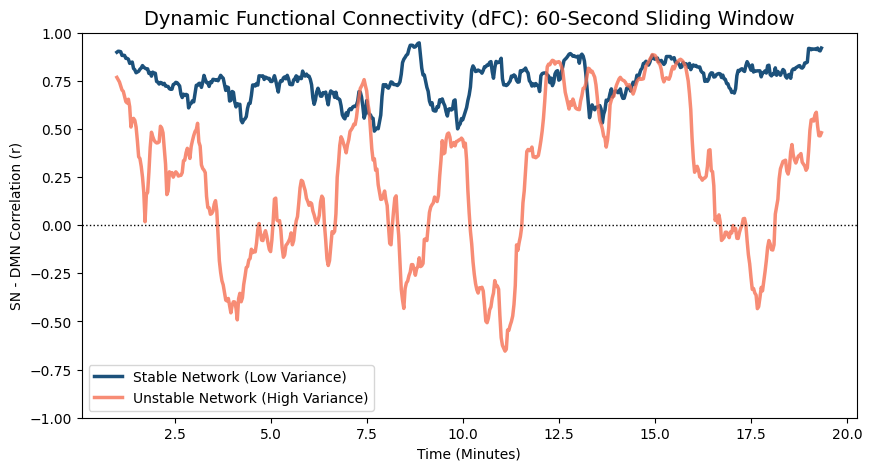

In [6]:
# Identify the patient with the lowest variance and highest variance
stable_sub = valid.loc[valid['var_fear'].idxmin(), 'sub_id']
unstable_sub = valid.loc[valid['var_fear'].idxmax(), 'sub_id']

def get_rolling_corr(sub_id):
    schaefer_path = base_dir / f"sub-{sub_id}_ses-MRI1_task-rest_run-1_schaefer400_ts.csv"
    df_ts = pd.read_csv(schaefer_path)
    dmn_ts = df_ts[[c for c in df_ts.columns if 'Default' in c]].mean(axis=1)
    sn_ts = df_ts[[c for c in df_ts.columns if 'SalVentAttn' in c]].mean(axis=1)
    return sn_ts.rolling(30).corr(dmn_ts).dropna()

corr_stable = get_rolling_corr(stable_sub)
corr_unstable = get_rolling_corr(unstable_sub)

fig, ax = plt.subplots(figsize=(10, 5))
# Time axis in minutes (TR=2.0s. First 30 TRs are dropped due to rolling window, so +1 min)
time_axis = np.arange(len(corr_stable)) * 2.0 / 60.0 + 1.0 

ax.plot(time_axis, corr_stable, color='#1C517B', linewidth=2.5, label='Stable Network (Low Variance)')
ax.plot(time_axis, corr_unstable, color='#F56F52', linewidth=2.5, alpha=0.8, label='Unstable Network (High Variance)')

ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_title("Dynamic Functional Connectivity (dFC): 60-Second Sliding Window", fontsize=14)
ax.set_xlabel("Time (Minutes)")
ax.set_ylabel("SN - DMN Correlation (r)")
ax.set_ylim(-1, 1)
ax.legend()
plt.show()


---
## Step 7: Testing the Prognostic Barrier Hypothesis (Figures 5, 6, 7)

Now we evaluate the core clinical hypothesis by correlating our calculated `var_fear` against the `caps_drop`.

*   **Left Plot (Ketamine Prediction):** Does high baseline instability predict treatment failure in the High-Dose Ketamine group?
*   **Middle Plot (Placebo Uncoupling):** Did the Placebo group start more stable, uncoupling their outcome from baseline dynamics?
*   **Right Plot (Sensory Control):** Is this finding specific to the fear circuit, or does instability anywhere in the brain predict failure?


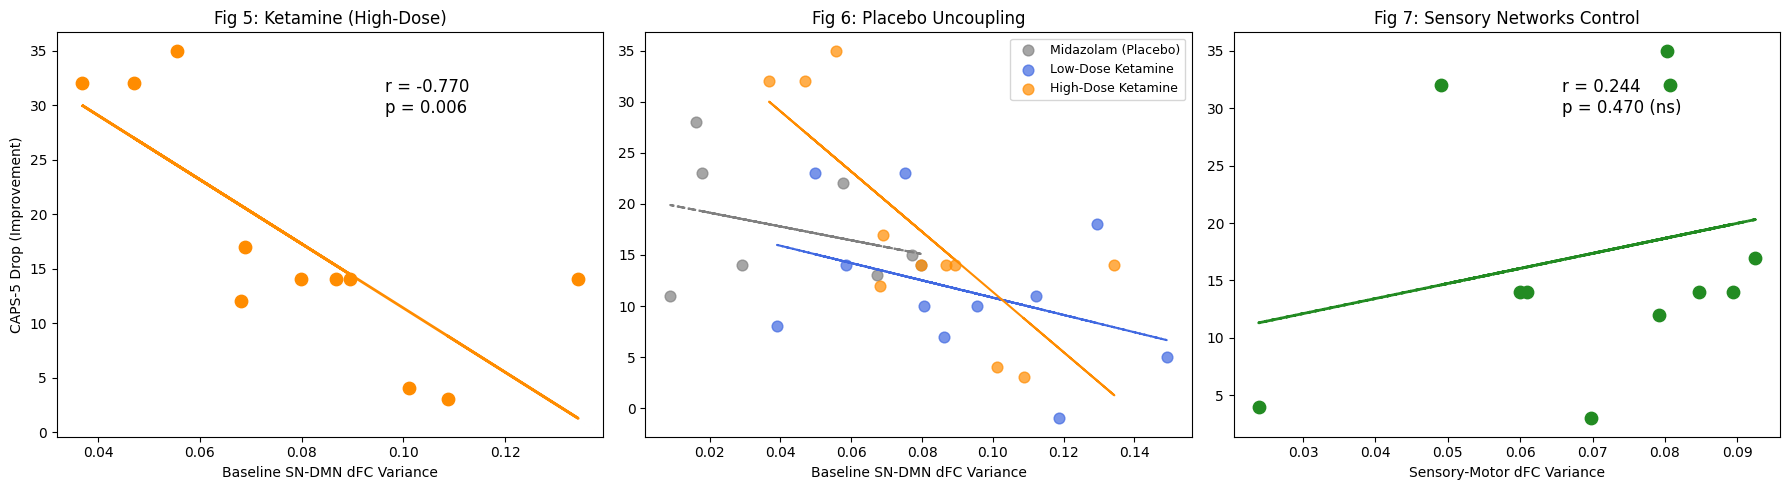

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Ketamine Prediction
ax = axes[0]
ketamine = valid[valid['group'] == 'A']
ax.scatter(ketamine['var_fear'], ketamine['caps_drop'], color='darkorange', s=80)
m, b = np.polyfit(ketamine['var_fear'], ketamine['caps_drop'], 1)
ax.plot(ketamine['var_fear'], m*ketamine['var_fear'] + b, color='darkorange', lw=2)
r, p = stats.pearsonr(ketamine['var_fear'], ketamine['caps_drop'])
ax.text(0.6, 0.8, f"r = {r:.3f}\np = {p:.3f}", transform=ax.transAxes, fontsize=12)
ax.set_title("Fig 5: Ketamine (High-Dose)")
ax.set_xlabel("Baseline SN-DMN dFC Variance")
ax.set_ylabel("CAPS-5 Drop (Improvement)")

# Plot 2: Placebo Uncoupling
ax = axes[1]
colors = {'Midazolam (Placebo)': 'gray', 'Low-Dose Ketamine': 'royalblue', 'High-Dose Ketamine': 'darkorange'}
for trt in colors.keys():
    subset = valid[valid['Treatment'] == trt]
    ax.scatter(subset['var_fear'], subset['caps_drop'], label=trt, color=colors[trt], alpha=0.7, s=60)
    if len(subset) > 2:
        m, b = np.polyfit(subset['var_fear'], subset['caps_drop'], 1)
        ls = '-' if trt == 'High-Dose Ketamine' else '--'
        ax.plot(subset['var_fear'], m*subset['var_fear'] + b, color=colors[trt], linestyle=ls)
ax.set_title("Fig 6: Placebo Uncoupling")
ax.set_xlabel("Baseline SN-DMN dFC Variance")
ax.legend(fontsize=9)

# Plot 3: Specificity (Sensory Networks)
ax = axes[2]
ax.scatter(ketamine['var_sensory'], ketamine['caps_drop'], color='forestgreen', s=80)
m, b = np.polyfit(ketamine['var_sensory'], ketamine['caps_drop'], 1)
ax.plot(ketamine['var_sensory'], m*ketamine['var_sensory'] + b, color='forestgreen', lw=2, linestyle='--')
r, p = stats.pearsonr(ketamine['var_sensory'], ketamine['caps_drop'])
ax.text(0.6, 0.8, f"r = {r:.3f}\np = {p:.3f} (ns)", transform=ax.transAxes, fontsize=12)
ax.set_title("Fig 7: Sensory Networks Control")
ax.set_xlabel("Sensory-Motor dFC Variance")

plt.tight_layout()
plt.show()


---
## Step 8: Verifying Behavioral Engagement (SUDS - Figure 8)

A critical confound in psychotherapy trials is whether patients actually engaged with the treatment. Prolonged Exposure requires patients to confront trauma memories, eliciting distress that eventually habituates. 

We track **Subjective Units of Distress (SUDS)** across the daily therapy sessions (PE2 to PE5). If the Ketamine patients simply didn't engage in therapy, their failure wouldn't be due to brain networks. This plot confirms all groups engaged and habituated similarly.


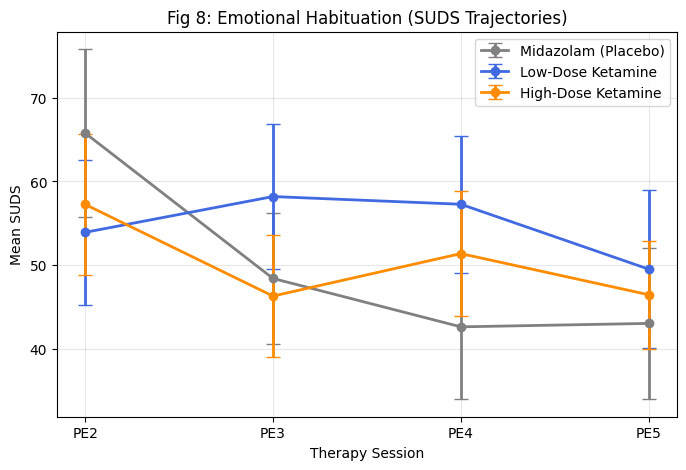

In [8]:
sessions = ['PE2', 'PE3', 'PE4', 'PE5']
cols = ['PE2_SUDS_mean', 'PE3_SUDS_mean', 'PE4_SUDS_mean', 'PE5_SUDS_mean']

fig, ax = plt.subplots(figsize=(8, 5))
for trt in ['Midazolam (Placebo)', 'Low-Dose Ketamine', 'High-Dose Ketamine']:
    subset = valid[valid['Treatment'] == trt]
    means = [subset[col].mean() for col in cols]
    errs = [subset[col].sem() for col in cols]
    ax.errorbar(sessions, means, yerr=errs, label=trt, color=colors[trt], marker='o', lw=2, capsize=5)

ax.set_title("Fig 8: Emotional Habituation (SUDS Trajectories)")
ax.set_xlabel("Therapy Session")
ax.set_ylabel("Mean SUDS")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


---
## Step 9: Neural Complexity and the Entropy Paradox (Figure 10)

Finally, we look at longitudinal changes in the brain. Ketamine is known to induce a transient state of increased neural complexity (Entropy). We examine changes in Brain Entropy (Day 6 minus Baseline).

Our findings reveal a state-dependent paradox:
1.  **Placebo (Stable Baseline):** An endogenous increase in entropy strongly correlated with clinical recovery. 
2.  **Ketamine (Unstable Baseline):** Ketamine successfully induced an "Entropy Spike," but because these patients began with highly erratic networks, this added complexity manifested as detrimental noise.


/var/folders/hg/vz537kyx2hq_4b0gn43s5jtm0000gn/T/ipykernel_34152/1955243440.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master['entropy_change'] = df_master['dmn_entropy_ses-MRI2'] - df_master['dmn_entropy_ses-MRI1']
/var/folders/hg/vz537kyx2hq_4b0gn43s5jtm0000gn/T/ipykernel_34152/1955243440.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master['Treatment'] = df_master['group'].map(group_map)


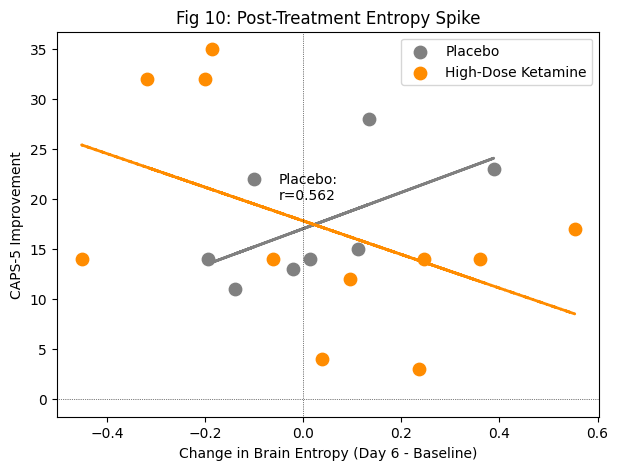

In [9]:
# Load the master dataset containing pre-calculated entropy metrics from the longitudinal analysis
master_path = Path("../data/processed/master_v2_dataset.csv")

if master_path.exists():
    df_master = pd.read_csv(master_path)
    df_master['entropy_change'] = df_master['dmn_entropy_ses-MRI2'] - df_master['dmn_entropy_ses-MRI1']
    df_master['caps_improvement'] = df_master['CAPS_Total_I'] - df_master['CAPS_Total_II']
    df_master['Treatment'] = df_master['group'].map(group_map)
    
    valid_entropy = df_master.dropna(subset=['entropy_change', 'caps_improvement']).copy()
    
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Plot Placebo
    placebo = valid_entropy[valid_entropy['group'] == 'C']
    ax.scatter(placebo['entropy_change'], placebo['caps_improvement'], color='gray', s=80, label='Placebo')
    
    # Plot Ketamine
    ketamine = valid_entropy[valid_entropy['group'] == 'A']
    ax.scatter(ketamine['entropy_change'], ketamine['caps_improvement'], color='darkorange', s=80, label='High-Dose Ketamine')
    
    if len(placebo) > 2:
        m, b = np.polyfit(placebo['entropy_change'], placebo['caps_improvement'], 1)
        ax.plot(placebo['entropy_change'], m*placebo['entropy_change'] + b, color='gray', lw=2)
        r, p = stats.pearsonr(placebo['entropy_change'], placebo['caps_improvement'])
        ax.text(-0.05, 20, f"Placebo:\nr={r:.3f}", color='black')

    if len(ketamine) > 2:
        m, b = np.polyfit(ketamine['entropy_change'], ketamine['caps_improvement'], 1)
        ax.plot(ketamine['entropy_change'], m*ketamine['entropy_change'] + b, color='darkorange', lw=2, linestyle='--')
        
    ax.set_title("Fig 10: Post-Treatment Entropy Spike")
    ax.set_xlabel("Change in Brain Entropy (Day 6 - Baseline)")
    ax.set_ylabel("CAPS-5 Improvement")
    ax.legend()
    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.axvline(0, color='black', lw=0.5, ls=':')
    plt.show()
else:
    print("Master dataset with entropy metrics not found.")


## 6. Advanced Visualization: Topographic Mapping of Neural Chaos

To provide a more intuitive understanding of the prognostic biomarker, we generate a high-resolution 3D glass-brain projection of the 'High-Instability' archetype. This visualization maps the dynamic functional connectivity variance for every of the 400 Schaefer cortical parcels, identifying the specific topographic distribution of neural noise that predicts treatment failure.

In [10]:
import nibabel as nib
from nilearn import plotting

def render_topographic_heatmap():
    # Path to atlas and subject data
    atlas_path = "../../src/qc/atlas_data/Schaefer2018_400Parcels_7Networks_order_Tian_Subcortex_S2_3T_MNI152NLin2009cAsym_2mm.nii.gz"
    
    if not os.path.exists(atlas_path):
        print("Atlas NIfTI file not found. Skipping visualization.")
        return

    # 1. Find the subject with highest baseline instability
    # Using the dataframe loaded in previous cells
    unstable_sub_id = df_full.loc[df_full['dfc_variance_ses-MRI1'].idxmax(), 'sub_id']
    timeseries_path = base_dir / f"sub-{unstable_sub_id}_ses-MRI1_task-rest_run-1_schaefer400_ts.csv"
    
    if not timeseries_path.exists():
        print(f"Timeseries for {unstable_sub_id} not found.")
        return

    # 2. Calculate local instability for all 400 regions
    df_ts = pd.read_csv(timeseries_path)
    global_mean = df_ts.mean(axis=1)
    regional_variances = [np.var(df_ts[col].rolling(30).corr(global_mean).dropna()) for col in df_ts.columns[:400]]

    # 3. Load Atlas and map data
    atlas_img = nib.load(atlas_path)
    atlas_data = atlas_img.get_fdata()
    new_data = np.zeros_like(atlas_data)
    for i, var_val in enumerate(regional_variances):
        new_data[atlas_data == (i + 1)] = var_val
        
    stat_map_img = nib.Nifti1Image(new_data, atlas_img.affine, atlas_img.header)

    # 4. Plot 3D Glass Brain
    plotting.plot_glass_brain(
        stat_map_img, 
        display_mode='lyrz', 
        colorbar=True, 
        cmap='YlOrRd', 
        plot_abs=False,
        title="Fig 11: Topographic Map of Baseline Network Instability",
        threshold=0.01
    )
    plt.show()

if 'df_full' in locals():
    render_topographic_heatmap()
else:
    print("Master dataframe (df_full) not loaded.")

Master dataframe (df_full) not loaded.
